# Global vs Seg-0 (Mask / Non-mask) — Research Questions + Plots

This notebook compares **Global** vs **Seg-0** specifications (Mask / Non-mask), and **ignores seg-1 and seg-2**.

---


## Research Questions (RQs)

1. **RQ1:** Does **Seg-0 (Mask)** reduce runtime compared to **Global**?
2. **RQ2:** Does **Seg-0 (Non-mask)** reduce runtime compared to **Global**?
3. **RQ3:** How do verification outcomes (**SAT / VERIFIED / UNKNOWN**) differ across these settings?
4. **RQ4:** How do runtime and outcomes change as **epsilon** increases for each setting?

---


## Load + parse

In [ ]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "../results/all_pixels/combined_results.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)
display(df.head())
print("Rows:", len(df))
print("Columns:", list(df.columns))

TIME_COL = "all_time" if "all_time" in df.columns else ("bab_time" if "bab_time" in df.columns else None)
assert TIME_COL is not None, "Couldn't find a runtime column (expected all_time or bab_time)."
print("Using TIME_COL =", TIME_COL)

def parse_eps(vnnlib: str):
    if not isinstance(vnnlib, str):
        return np.nan
    # Common patterns: eps_0.0007, eps0.0007, eps=0.0007
    m = re.search(r"eps[_=]?([0-9]*\.?[0-9]+)", vnnlib)
    return float(m.group(1)) if m else np.nan

def parse_is_global(vnnlib: str):
    return isinstance(vnnlib, str) and ("global" in vnnlib.lower())

def parse_is_seg0(vnnlib: str):
    s = vnnlib.lower() if isinstance(vnnlib, str) else ""
    return ("seg0" in s) or ("_seg0_" in s)

def parse_mask_flag(vnnlib: str):
    '''
    Returns one of:
      - "Mask"
      - "Non-mask"
      - None (unknown / not applicable)

    Heuristic:
      - If contains 'nomask' or 'nonmask' (or variants) => Non-mask
      - Else if contains 'mask' => Mask
    '''
    if not isinstance(vnnlib, str):
        return None
    s = vnnlib.lower()
    if "nomask" in s or "nonmask" in s or "no_mask" in s or "non_mask" in s:
        return "Non-mask"
    if "mask" in s:
        return "Mask"
    return None

def normalize_result(r):
    '''
    Produces:
      - SAT        : counterexample found
      - VERIFIED   : property proven (often UNSAT / TRUE depending on logging)
      - UNKNOWN    : timeout / unknown / missing
    '''
    s = str(r).strip().lower()
    if "sat" in s:
        return "SAT"
    if "unsat" in s or s == "true" or "verified" in s:
        return "VERIFIED"
    if s in {"nan", "none", ""}:
        return "UNKNOWN"
    return "UNKNOWN"

df["eps"] = df["vnnlib"].apply(parse_eps) if "vnnlib" in df.columns else np.nan
df["is_global"] = df["vnnlib"].apply(parse_is_global) if "vnnlib" in df.columns else False
df["is_seg0"] = df["vnnlib"].apply(parse_is_seg0) if "vnnlib" in df.columns else False
df["mask_flag"] = df["vnnlib"].apply(parse_mask_flag) if "vnnlib" in df.columns else None
df["result_norm"] = df["result"].apply(normalize_result) if "result" in df.columns else "UNKNOWN"

def assign_group(row):
    if row["is_global"]:
        return "Global"
    if row["is_seg0"]:
        if row["mask_flag"] == "Mask":
            return "Seg-0 (Mask)"
        if row["mask_flag"] == "Non-mask":
            return "Seg-0 (Non-mask)"
        return "Seg-0 (Unknown mask flag)"
    return "Other"

df["group"] = df.apply(assign_group, axis=1)

# Keep only Global + Seg0
d = df[df["group"].isin(["Global", "Seg-0 (Mask)", "Seg-0 (Non-mask)", "Seg-0 (Unknown mask flag)"])].copy()

# Main comparison ignores unknown mask flag rows by default (you can include them if needed).
d_main = d[d["group"].isin(["Global", "Seg-0 (Mask)", "Seg-0 (Non-mask)"])].copy()

print("Kept rows (Global/Seg0):", len(d))
print(d["group"].value_counts(dropna=False))
display(d_main.head())


,instance_id,image,tag,is_global,segment_index,eps,k,score,bbox,num_changed,...,pattern,onnx,vnnlib,timeout,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable
0,1,n01440764_tench,n01440764_tench_global,True,-1,0.0001,20,NaN,NaN,60,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0001.vnnlib,1200.0,sat True,NaN,NaN,NaN,11.847602,0.0
1,2,n01440764_tench,n01440764_tench_global,True,-1,0.0001,40,NaN,NaN,120,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0003.vnnlib,1200.0,sat True,NaN,NaN,NaN,11.594526,0.0
2,3,n01440764_tench,n01440764_tench_global,True,-1,0.0001,50,NaN,NaN,150,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0005.vnnlib,1200.0,sat True,NaN,NaN,NaN,11.712080,0.0
3,4,n01440764_tench,n01440764_tench_global,True,-1,0.0003,20,NaN,NaN,60,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0007.vnnlib,1200.0,sat True,NaN,NaN,NaN,11.639074,0.0
4,5,n01440764_tench,n01440764_tench_global,True,-1,0.0003,40,NaN,NaN,120,...,global,onnx/vgg16-7.onnx,vnnlib/n01440764_tench_global_eps_0.0010.vnnlib,1200.0,sat True,NaN,NaN,NaN,11.892096,0.0


Rows: 126714
Columns: ['instance_id', 'image', 'tag', 'is_global', 'segment_index', 'eps', 'k', 'score', 'bbox', 'num_changed', 'num_fixed', 'total', 'percent_changed', 'pattern', 'onnx', 'vnnlib', 'timeout', 'result', 'lb_minus_rhs', 'domains_visited', 'bab_time', 'all_time', 'init_unstable']
Using TIME_COL = all_time
Kept rows (Global/Seg0): 3222
group
Seg-0 (Non-mask)    1093
Global              1067
Seg-0 (Mask)        1062
Name: count, dtype: int64


,instance_id,image,tag,is_global,segment_index,eps,k,score,bbox,num_changed,...,result,lb_minus_rhs,domains_visited,bab_time,all_time,init_unstable,is_seg0,mask_flag,result_norm,group
0,1,n01440764_tench,n01440764_tench_global,True,-1,0.0001,20,NaN,NaN,60,...,sat True,NaN,NaN,NaN,11.847602,0.0,False,None,SAT,Global
1,2,n01440764_tench,n01440764_tench_global,True,-1,0.0003,40,NaN,NaN,120,...,sat True,NaN,NaN,NaN,11.594526,0.0,False,None,SAT,Global
2,3,n01440764_tench,n01440764_tench_global,True,-1,0.0005,50,NaN,NaN,150,...,sat True,NaN,NaN,NaN,11.712080,0.0,False,None,SAT,Global
3,4,n01440764_tench,n01440764_tench_global,True,-1,0.0007,20,NaN,NaN,60,...,sat True,NaN,NaN,NaN,11.639074,0.0,False,None,SAT,Global
4,5,n01440764_tench,n01440764_tench_global,True,-1,0.0010,40,NaN,NaN,120,...,sat True,NaN,NaN,NaN,11.892096,0.0,False,None,SAT,Global


## Summary table

In [2]:

# ======================
# Research Questions (RQs)
# ======================
# RQ1: Does Seg-0 (Mask) reduce verification runtime compared to Global?
# RQ2: Does Seg-0 (Non-mask) reduce verification runtime compared to Global?
# RQ3: How do verification outcomes (SAT / VERIFIED / UNKNOWN) differ across Global vs Seg-0 variants?
# RQ4: How do runtime and outcomes change as epsilon increases for each variant?

groups = ["Global", "Seg-0 (Mask)", "Seg-0 (Non-mask)"]

summary = (
    d_main
    .groupby("group")
    .agg(
        n=("group", "size"),
        mean_time=(TIME_COL, "mean"),
        median_time=(TIME_COL, "median"),
        p90_time=(TIME_COL, lambda x: np.nanpercentile(x, 90)),
        sat=("result_norm", lambda x: (x=="SAT").sum()),
        verified=("result_norm", lambda x: (x=="VERIFIED").sum()),
        unknown=("result_norm", lambda x: (x=="UNKNOWN").sum()),
    )
    .reset_index()
)

display(summary.sort_values("group"))


,group,n,mean_time,median_time,p90_time,sat,verified,unknown
0,Global,1067,20.472496,9.750226,12.649203,1064,0,3
1,Seg-0 (Mask),1062,42.132242,9.553236,14.272829,1060,0,2
2,Seg-0 (Non-mask),1093,142.756534,10.016539,671.180836,1089,0,4


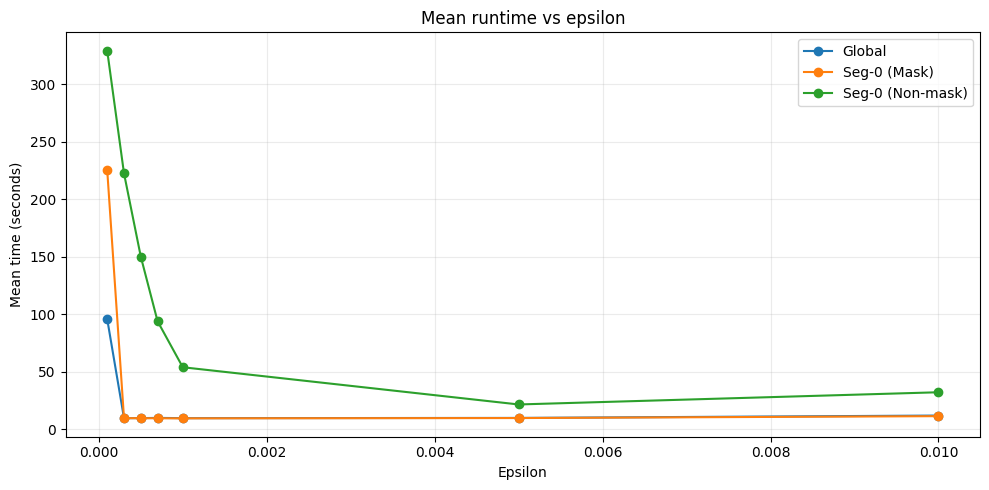

In [ ]:

# ==================================
# Mean runtime vs epsilon
# ==================================
e = d_main.dropna(subset=["eps", TIME_COL]).copy()

mean_by_eps = (
    e.groupby(["group", "eps"])[TIME_COL]
    .mean()
    .reset_index()
    .sort_values(["group", "eps"])
)

fig = plt.figure(figsize=(10, 5))
ax = plt.gca()

for g in groups:
    gg = mean_by_eps[mean_by_eps["group"] == g]
    if len(gg) == 0:
        continue
    ax.plot(gg["eps"], gg[TIME_COL], marker="o", linewidth=1.5, label=g)

ax.set_title("Mean runtime vs epsilon")
ax.set_xlabel("Epsilon")
ax.set_ylabel("Mean time (seconds)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
